k=2, silhouette=0.2700
k=3, silhouette=0.1371
k=4, silhouette=0.1449
k=5, silhouette=0.1351
k=6, silhouette=0.1352

Best k by silhouette: 2

=== Cluster-to-Label Evaluation Metrics ===
Accuracy : 0.5861
F1-score : 0.3945
Precision: 0.7147
Recall   : 0.2724
Silhouette (best k=2): 0.2700


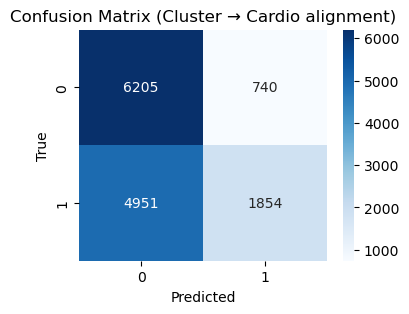

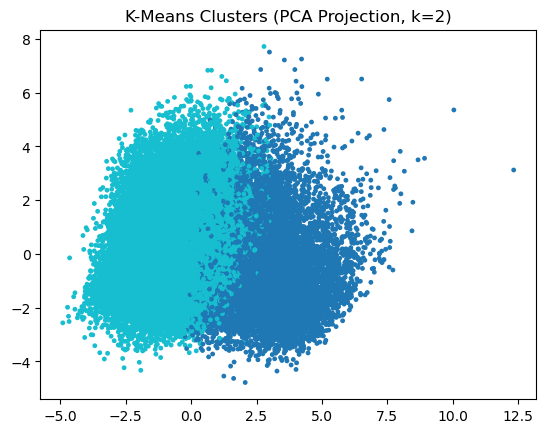

In [1]:
# 4 - K-MEANS CLUSTERING 
import pandas as pd, numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


# Load and preprocess dataset

df = pd.read_csv("processed_cardio_dataset.csv", sep=None, engine='python')
if 'id' in df.columns:
    df = df.drop('id', axis=1)
df = df.replace({True: 1, False: 0})
label_col = 'cardio'

X = df.drop(label_col, axis=1)
y = df[label_col]


scaler = StandardScaler()
X_s = scaler.fit_transform(X)


# Choose best k using silhouette score

scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labs = km.fit_predict(X_s)
    sil = silhouette_score(X_s, labs)
    scores[k] = sil
    print(f"k={k}, silhouette={sil:.4f}")

best_k = max(scores, key=scores.get)
print("\nBest k by silhouette:", best_k)


# Fit final KMeans model

km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = km.fit_predict(X_s)


# Evaluate alignment with true labels

X_train, X_test, y_train, y_test = train_test_split(
    X_s, y, test_size=0.2, random_state=42, stratify=y
)

km_full = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit(np.vstack([X_train, X_test]))
labels_test = km_full.predict(X_test)

# Because cluster labels can be flipped (0↔1)
acc1 = accuracy_score(y_test, labels_test)
acc2 = accuracy_score(y_test, 1 - labels_test)

if acc2 > acc1:
    labels_test = 1 - labels_test  # flip labels for correct orientation


# Compute metrics

acc = accuracy_score(y_test, labels_test)
f1 = f1_score(y_test, labels_test)
prec = precision_score(y_test, labels_test)
rec = recall_score(y_test, labels_test)
cm = confusion_matrix(y_test, labels_test)

print("\n=== Cluster-to-Label Evaluation Metrics ===")
print(f"Accuracy : {acc:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"Silhouette (best k={best_k}): {scores[best_k]:.4f}")

# Confusion Matrix visualization
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Cluster → Cardio alignment)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# -----------------------------
# PCA Visualization
# -----------------------------
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_s)
plt.scatter(pcs[:, 0], pcs[:, 1], c=labels, s=6, cmap='tab10')
plt.title(f"K-Means Clusters (PCA Projection, k={best_k})")
plt.show()
